# P-ion optimisation of SUMOylation searches in MQ

In this notebook, the searches p-ion searches are analysed. In these searches the p-ions were searched for one by one, to identify potenetial differences in identification rate.  

This anlaysis was the foundtation to understanding which p-ion, indivisually yielded the most identifications of SUMOylates peptides. 

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

plt.rcParams["font.family"] = "Arial" 

In [42]:
root_dir = '.../p_ion_opt_final_sumo'


In [ ]:
dfs = []

for subdir, _, files in os.walk(root_dir):
    for file in files:
        if file == 'msms.txt':
            file_path = os.path.join(subdir, file)
            # Get the parent directory one level up
            parent_folder = os.path.basename(os.path.dirname(subdir))
            print(file_path)
            df = pd.read_csv(file_path, delimiter="\t")
            
            new_columns = {}
            for col in df.columns:
                if 'SUMO2/3' in col:
                    new_col_name = 'SUMO2/3' + col.split('SUMO2/3', 1)[1]
                    new_columns[col] = new_col_name
            
            df.rename(columns=new_columns, inplace=True)
            df['Dataset'] = parent_folder
            print(parent_folder)
            print("adding")
            dfs.append(df)

big_df = pd.concat(dfs, ignore_index=True)


In [6]:
big_df = big_df[big_df['Contaminant'] != '+']
big_df['Reverse'].fillna('-', inplace=True)

In [23]:
# sumo dataset 
df_sumo = big_df[big_df['SUMO2/3-DVFQQQTGG'] == 1] 
df_no_sumo = big_df[big_df['SUMO2/3-DVFQQQTGG'] == 0] 

In [24]:
# unique sites and peptides  
df_sumo_unique = df_sumo.groupby('Dataset').apply(lambda x: x.drop_duplicates(subset=['Modified sequence'], keep='last')).reset_index(drop=True)
df_unique = df_no_sumo.groupby('Dataset').apply(lambda x: x.drop_duplicates(subset=['Modified sequence'], keep='last')).reset_index(drop=True)

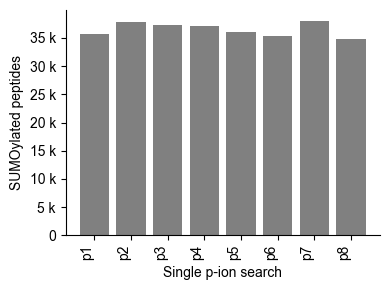

In [56]:
filtered_big_df = df_sumo[df_sumo['Reverse'] != '+']
filtered_counts = filtered_big_df.groupby('Dataset').size()

fig, ax = plt.subplots(figsize=(4, 3))
bars = ax.bar(filtered_counts.index, filtered_counts.values, color='grey')

ax.set_xlabel('Single p-ion search')
ax.set_ylabel('SUMOylated peptides')
ax.set_title('')
ax.set_xticks(filtered_counts.index) 
ax.set_xticklabels(filtered_counts.index, ha='right',rotation=90)  # rotation=45,  
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()
file_path = fig_dir + "sumo_ps.pdf"
plt.savefig(file_path, transparent=True)
plt.show()


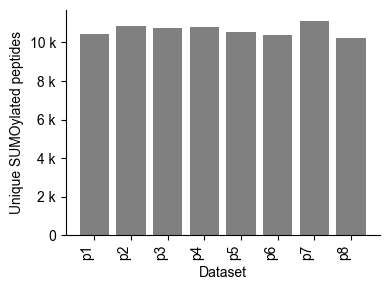

In [45]:
filtered_big_df_unique = df_sumo_unique[df_sumo_unique['Reverse'] != '+']
filtered_counts_unique = filtered_big_df_unique.groupby('Dataset').size()

fig, ax = plt.subplots(figsize=(4, 3))
bars_un = ax.bar(filtered_counts_unique.index, filtered_counts_unique.values, color='grey')

ax.set_xlabel('Dataset')
ax.set_ylabel('Unique SUMOylated peptides')
ax.set_title('')
ax.set_xticks(filtered_counts_unique.index) 
ax.set_xticklabels(filtered_counts_unique.index, ha='right',rotation=90) # rotation=45,  

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_formatter(ticker.EngFormatter())
file_path = fig_dir + "sumo_ps.pdf"
plt.tight_layout()
plt.show()

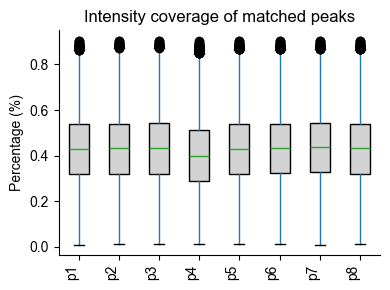

In [49]:
combined_data = filtered_big_df.pivot(columns='Dataset', values='Intensity coverage')

fig, ax = plt.subplots(figsize=(4, 3))
boxprops = dict(facecolor='lightgrey', color='black')
combined_data.boxplot(ax=ax, widths=0.5, boxprops=boxprops, patch_artist=True)

ax.set_title('Intensity coverage of matched peaks')
ax.set_ylabel('Percentage (%)')

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.grid(False)
ax.set_xticklabels(ax.get_xticklabels(), ha='right',rotation=90) # rotation=45,
plt.tight_layout()
plt.show()


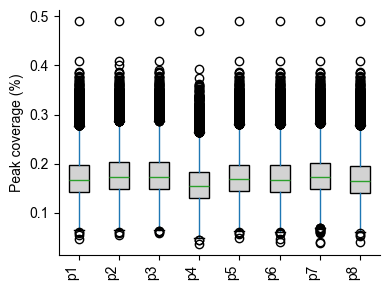

In [54]:
combined_data = filtered_big_df.pivot(columns='Dataset', values='Peak coverage')

fig, ax = plt.subplots(figsize=(4, 3))
boxprops = dict(facecolor='lightgrey', color='black')
combined_data.boxplot(ax=ax, widths=0.5, boxprops=boxprops, patch_artist=True)

ax.set_title('')
ax.set_ylabel('Peak coverage (%)')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.grid(False)
ax.set_xticklabels(ax.get_xticklabels(), ha='right',rotation=90) #  rotation=45, 
plt.tight_layout()
plt.show()


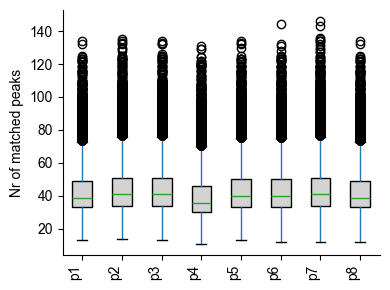

In [52]:
combined_data = filtered_big_df.pivot(columns='Dataset', values='Number of matches')

fig, ax = plt.subplots(figsize=(4, 3))
boxprops = dict(facecolor='lightgrey', color='black')
combined_data.boxplot(ax=ax, widths=0.5, boxprops=boxprops, patch_artist=True)

ax.set_title('')
ax.set_ylabel('Nr of matched peaks')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.grid(False)
ax.set_xticklabels(ax.get_xticklabels(), ha='right',rotation=90) 
plt.tight_layout()
plt.show()